In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 1000)
pd.options.display.float_format = '{:,.2f}'.format

from sklearn import preprocessing
from scipy.stats import chi2_contingency

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
#import category_encoders as ce

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix

In [2]:
#%pip install xgboost

In [3]:
product_target = 'fam_payment_card'
save_path = 'data/df_' + product_target + '.csv'
save_path

'data/df_fam_payment_card.csv'

In [4]:
df = pd.read_csv(save_path)
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [5]:
# Nos quedamos con los clientes vivos para luego descartar los muertos de la predicción:
df_non_deceased_last_partition = df[(df["pk_partition"]==df["pk_partition"].max())&(df["deceased"]=='N')].drop_duplicates()
df_non_deceased_last_partition

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,payroll,pension_plan,payroll_account,emc_account,em_account_p,em_acount,z_months_since_entry,z_pct_months_active,z_partition_segment_changed,z_segment_mode,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,y
16,1000096,2019-05-01,2015-01-01,KFA,1.00,02 - PARTICULARES,ES,28.00,H,10,N,0.00,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,53.00,1.00,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
39,1000113,2019-05-01,2015-04-01,KAT,0.00,02 - PARTICULARES,ES,14.00,V,54,N,"136,705.50",0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,50.00,0.00,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
50,1000130,2019-05-01,2018-03-01,KAT,1.00,02 - PARTICULARES,ES,28.00,H,44,N,"126,133.50",0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,14.00,0.27,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
60,1000157,2019-05-01,2016-03-01,KFC,1.00,02 - PARTICULARES,ES,46.00,V,44,N,"68,038.20",0,0,0,0,0,0,0,0.00,0.00,0,0,0,1,39.00,0.94,0,02 - PARTICULARES,0,0,1.00,1,0.00,0.00
76,1000162,2019-05-01,2018-02-01,RED,1.00,02 - PARTICULARES,ES,24.00,H,36,N,"108,248.76",0,0,0,0,0,0,0,0.00,0.00,0,0,0,1,15.00,1.00,0,02 - PARTICULARES,0,0,1.00,1,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5293262,998325,2019-05-01,2016-07-01,KFC,1.00,02 - PARTICULARES,ES,46.00,V,34,N,"70,109.85",0,0,0,0,0,0,0,0.00,0.00,0,0,0,1,34.00,1.00,0,02 - PARTICULARES,0,0,1.00,1,0.00,0.00
5293275,998837,2019-05-01,2018-05-01,KAT,1.00,02 - PARTICULARES,ES,41.00,V,37,N,"113,316.87",0,0,0,0,0,0,0,0.00,0.00,0,0,0,1,12.00,1.00,0,02 - PARTICULARES,0,0,1.00,1,0.00,0.00
5293281,999706,2019-05-01,2018-12-01,KFC,0.00,02 - PARTICULARES,ES,28.00,H,14,N,0.00,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,5.00,0.17,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
5293298,999825,2019-05-01,2017-01-01,KFC,1.00,02 - PARTICULARES,ES,48.00,V,40,N,"108,659.43",0,0,0,0,0,0,0,0.00,0.00,0,0,0,1,28.00,1.00,0,02 - PARTICULARES,0,0,1.00,1,0.00,0.00


# 1. Features Analysis and Transformation before Modelling

In [6]:
df.head()

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,payroll,pension_plan,payroll_account,emc_account,em_account_p,em_acount,z_months_since_entry,z_pct_months_active,z_partition_segment_changed,z_segment_mode,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,y
0,1000096,2018-01-01,2015-01-01,KFA,1.00,02 - PARTICULARES,ES,28.00,H,9,N,0.00,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,37.00,1.00,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
1,1000096,2018-02-01,2015-01-01,KFA,1.00,02 - PARTICULARES,ES,28.00,H,9,N,0.00,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,38.00,1.00,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
2,1000096,2018-03-01,2015-01-01,KFA,1.00,02 - PARTICULARES,ES,28.00,H,9,N,0.00,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,38.00,1.00,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
3,1000096,2018-04-01,2015-01-01,KFA,1.00,02 - PARTICULARES,ES,28.00,H,9,N,0.00,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,40.00,1.00,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
4,1000096,2018-05-01,2015-01-01,KFA,1.00,02 - PARTICULARES,ES,28.00,H,9,N,0.00,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,41.00,1.00,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00


In [7]:
# columnas que borramos de partida:
df.drop(columns=['entry_date','z_segment_mode'], inplace=True)

## Global functions

### Correlations

In [8]:
def matriz_correlacion_numeric_features(df):
    numeric_df = df.select_dtypes(include=['number'])

    correlation_matrix = numeric_df.corr(method='pearson')

    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title('Matriz de Correlación (Pearson)')
    plt.show()

In [9]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    if min(k-1, r-1) == 0:
        return 0.0 
    return np.sqrt((chi2/n) / (min(k-1, r-1)))

def calculate_cramers_v_matrix(df, columns):
    """
    Calculates Cramér's V matrix for a list of categorical columns in a DataFrame.

    Args:
        df: The input pandas DataFrame.
        columns: A list of column names to calculate the Cramér's V matrix for.

    Returns:
        A pandas DataFrame representing the Cramér's V matrix.
    """
    cramer_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)

    for col1 in columns:
        for col2 in columns:
            if col1 == col2:
                cramer_matrix.loc[col1, col2] = 1.0
            else:
                cramer_matrix.loc[col1, col2] = cramers_v(
                    df[col1].astype(str), df[col2].astype(str)
                )
    return cramer_matrix

In [10]:
def matriz_correlacion_object_features(dfg,listdf):
  cramer_matrix = calculate_cramers_v_matrix(dfg, listdf)

  plt.figure(figsize=(8,6))
  sns.heatmap(cramer_matrix.astype(float), annot=True, cmap="Blues")
  plt.title("Colinealidad (Cramér's V)")
  plt.show()

### Processing

In [11]:
def group_minor_categories(df, col, threshold):
    """
    Agrupa las categorías poco frecuentes de una columna en 'Other'.
    """
    df[col] = df[col].fillna('Unknown').astype(str)
    value_counts = df[col].value_counts(normalize=True)
    minor_categories = value_counts[value_counts < threshold].index
    df[f"{col}_grouped"] = df[col].replace(minor_categories, 'Other')

    return df


### Feature Engineering

In [12]:
def frequency_encode(df, features_to_encode, normalize=True):
    """
    Aplica Frequency Encoding a una columna categórica,
    crea una nueva columna '<columna>_freq' y elimina la original.
    """

    for feature in features_to_encode:
        freq_encoding = df[feature].value_counts(normalize=normalize)
        new_column_name = f"{feature}_freq"
        df[new_column_name] = df[feature].map(freq_encoding)
        df.drop(columns=[feature], inplace=True)
        
    return df

In [13]:
def one_hot_encode(df, features_to_encode):
    """
    Applies one-hot encoding to a list of specified features in a DataFrame using scikit-learn.
    """
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded = encoder.fit_transform(df[features_to_encode])
    
    encoded_df = pd.DataFrame(
        encoded, 
        columns=encoder.get_feature_names_out(features_to_encode),
        index=df.index
    )
    
    df = df.drop(columns=features_to_encode)
    df = pd.concat([df, encoded_df], axis=1)

    return df

In [14]:
def normalize_features(df, features_to_normalize):
    """
    Normalizes a list of specified features in a DataFrame to a range between 0 and 1.
    """

    scaler = MinMaxScaler()
    df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])
    
    return df

----------------------------------------------------------

In [15]:
stats = []
for col in df.columns:
    stats.append((col, df[col].nunique(), df[col].isnull().sum() * 100 / df.shape[0], df[col].value_counts(normalize=True, dropna=False).values[0] * 100, df[col].dtype))

stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% missing values', '% values in biggest category', 'type'])
stats_df = stats_df.sort_values(by=[ '% values in biggest category','Unique_values'], ascending=[False, True])

In [16]:
filtered_stats_categoricas = stats_df[(stats_df['type'] != 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
17,em_account_pp,1,0.00,100.00,int64
22,em_account_p,2,0.00,100.00,int64
13,mortgage,2,0.00,100.00,int64
12,loans,2,0.00,100.00,int64
27,z_churn_customer_flag,2,0.00,99.76,int64
11,short_term_deposit,2,0.00,99.75,int64
15,securities,2,0.00,99.74,int64
14,funds,2,0.00,99.71,int64
32,y,2,0.00,99.66,float64
26,z_partition_segment_changed,2,0.00,98.98,int64


In [17]:
filtered_stats_categoricas = stats_df[(stats_df['type'] == 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
9,deceased,2,0.00,99.98,object
5,country_id,40,0.00,99.97,object
4,segment,3,0.00,72.35,object
2,entry_channel,66,0.00,59.22,object
7,gender,2,0.00,52.78,object
1,pk_partition,17,0.00,7.41,object


Decisiones:
- Borramos "deceased" por tener el 99% de los registros con el mismo valor
- Borramos "country_id" por tener el 99% de los registros con el mismo. Dejamos el region_code que está relleno cuando el pais es España y hay mas variabilidad.
- "segment" y "gender" OHE 
- "entry_channel" agrupar y luego OHE

In [18]:
df.drop(columns=['deceased','country_id'], inplace=True)

### 1.0 Correlations

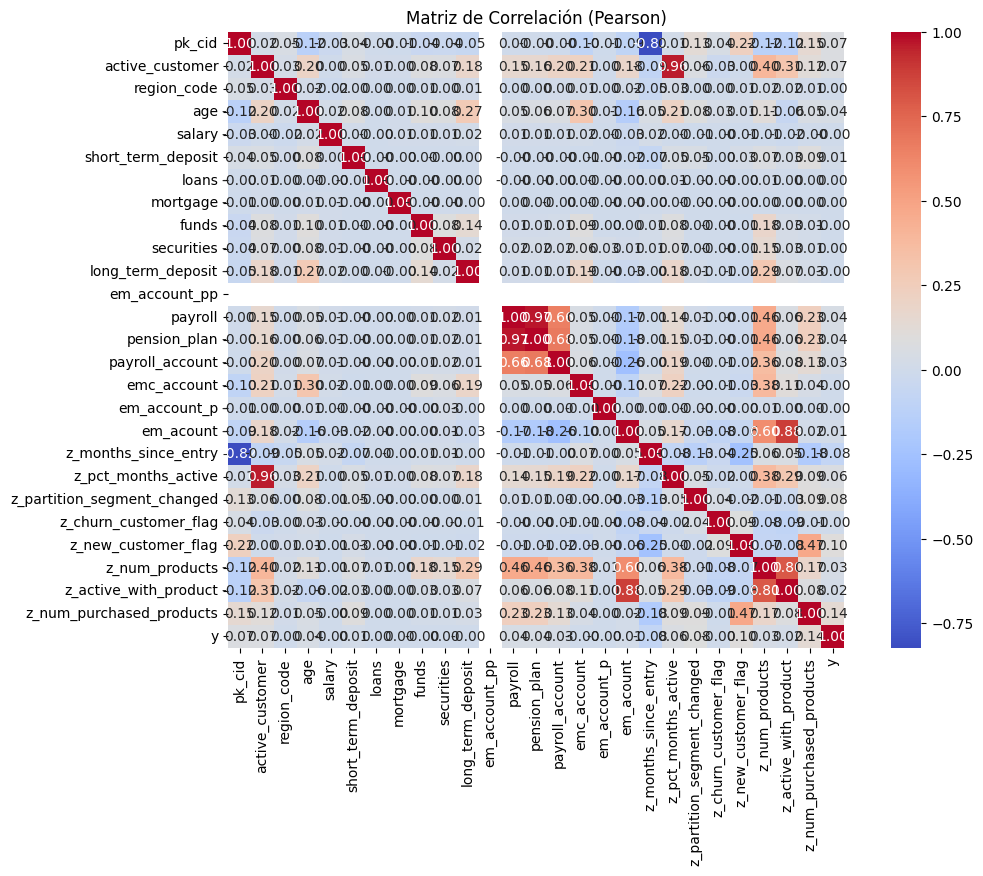

In [19]:
matriz_correlacion_numeric_features(df)

In [20]:
df.em_acount.value_counts(normalize=True)

em_acount
1   0.75
0   0.25
Name: proportion, dtype: float64

In [21]:
# Borramos "z_pct_months_active" por estar al 90% correlada con "active_customer" y "payroll_account" porque es igual que "payroll", borramos 'payroll' por altisima correlacion con pension plan
df.drop(columns=['z_pct_months_active', 'payroll_account', 'payroll', 'em_account_pp', 'em_account_p'], inplace=True)

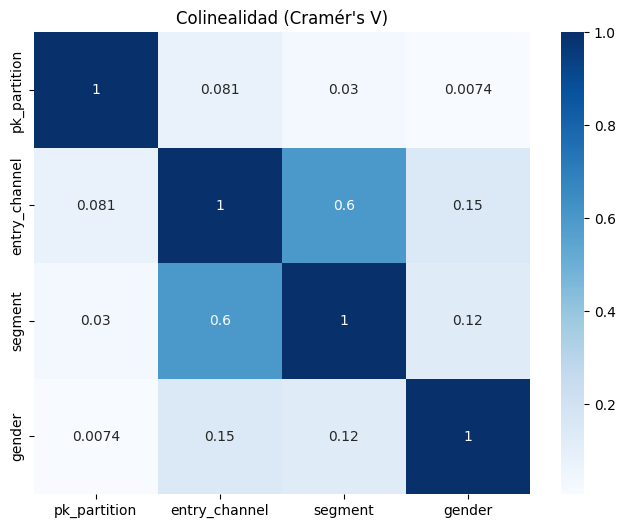

In [22]:
object_cols= df.select_dtypes(exclude=['number']).columns
matriz_correlacion_object_features(df, object_cols)

### 1.1 Fechas - estacionalidad 

In [23]:
df['pk_partition'] = pd.to_datetime(df['pk_partition'])

# Variables temporales
df['month'] = df['pk_partition'].dt.month
df['day_of_year'] = df['pk_partition'].dt.dayofyear
df['weekday'] = df['pk_partition'].dt.weekday  # 0 = lunes, 6 = domingo

# Transformación cíclica (reloj):
# Mes (12 meses)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
# Día del año (365 días)
df['dayofyear_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)
# Día de la semana (7 días)
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

In [24]:
df.drop(columns={'month','day_of_year','weekday'}, inplace = True)

### 1.2 Encoding

In [25]:
df = group_minor_categories(df, 'entry_channel', 0.01)
df.drop(columns='entry_channel', inplace=True)

df.rename(columns={'entry_channel_grouped':'entry_channel'}, inplace=True)

In [26]:
# df = group_minor_categories(df, 'region_code', 0.005)
# df.drop(columns='region_code', inplace=True)

Mejor no agrupamos la región y le hacemos el Frequency Encoding que consideramos que nos va a aportar más información.

In [27]:
# Frequency Encoding:
freqenc_cols = ['region_code']
df = frequency_encode(df, freqenc_cols)

In [28]:
# One Hot Encoding:
ohe_cols = ['entry_channel','segment','gender']
df = one_hot_encode(df, ohe_cols)

### 1.3 Normalization

In [29]:
normalize_cols = ['age','salary','z_months_since_entry','z_num_products','z_num_purchased_products']

df = normalize_features(df, normalize_cols)

# 2. Modelling

In [30]:
# reordenamos dejando el target al final
col = df.pop("y")
df["y"] = col

In [31]:
print(df.shape)

(5311461, 44)


In [32]:
# localizamos la última partición:
max_partition = df.pk_partition.max()

# 1. la guardamos en otro df para la predicción final
df_last_partition = df[df["pk_partition"]==max_partition] 
# 2. borramos los registros de la última partición porque no sabemos lo que pasa al mes siguiente
df = df[df["pk_partition"]!=max_partition]
print(df.shape)

(4917635, 44)


In [33]:
# localizamos la penúltima partición (SET DE VALIDACIÓN):
unique_parts = sorted(df.pk_partition.unique())
second_last_partition = unique_parts[-1]

# 1. la guardamos en otro df_val 
df_val = df[df["pk_partition"]==second_last_partition] 
# 2. borramos los registros de la partición de validación
df = df[df["pk_partition"]!=second_last_partition]
print(df.shape)

(4525684, 44)


In [34]:
df.head()

,pk_cid,pk_partition,active_customer,age,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,pension_plan,emc_account,em_acount,z_months_since_entry,z_partition_segment_changed,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,month_sin,month_cos,dayofyear_sin,dayofyear_cos,weekday_sin,weekday_cos,region_code_freq,entry_channel_KAT,entry_channel_KFA,entry_channel_KFC,entry_channel_KHD,entry_channel_KHE,entry_channel_KHK,entry_channel_KHM,entry_channel_KHN,entry_channel_KHQ,entry_channel_Other,segment_01 - TOP,segment_02 - PARTICULARES,segment_03 - UNIVERSITARIO,gender_H,gender_V,y
0,1000096,2018-01-01,1.00,0.07,0.00,0,0,0,0,0,0,0.00,0,0,0.70,0,0,0,0.00,0,0.00,0.50,0.87,0.02,1.00,0.00,1.00,0.19,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
1,1000096,2018-02-01,1.00,0.07,0.00,0,0,0,0,0,0,0.00,0,0,0.72,0,0,0,0.00,0,0.00,0.87,0.50,0.52,0.85,0.43,-0.90,0.19,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
2,1000096,2018-03-01,1.00,0.07,0.00,0,0,0,0,0,0,0.00,0,0,0.72,0,0,0,0.00,0,0.00,1.00,0.00,0.86,0.51,0.43,-0.90,0.19,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
3,1000096,2018-04-01,1.00,0.07,0.00,0,0,0,0,0,0,0.00,0,0,0.75,0,0,0,0.00,0,0.00,0.87,-0.50,1.00,0.00,-0.78,0.62,0.19,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
4,1000096,2018-05-01,1.00,0.07,0.00,0,0,0,0,0,0,0.00,0,0,0.77,0,0,0,0.00,0,0.00,0.50,-0.87,0.87,-0.49,0.78,0.62,0.19,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00


In [35]:
df.y.value_counts()

y
0.00    4509019
1.00      16665
Name: count, dtype: int64

### 2.1 Undersampling

In [36]:
df_model = df.copy()

df_pos = df_model[df_model["y"] == 1]
df_neg = df_model[df_model["y"] == 0]

ratio = 3 
df_neg_sample = df_neg.sample(n=len(df_pos)*ratio, random_state=42)

df_balanced = pd.concat([df_pos, df_neg_sample], ignore_index=True).sample(frac=1, random_state=42)

X_bal = df_balanced.drop(columns=["y", "pk_cid", "pk_partition"])
y_bal = df_balanced["y"]

In [37]:
df_balanced.y.value_counts(normalize=True)

y
0.00   0.75
1.00   0.25
Name: proportion, dtype: float64

### 2.2 Model

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

model_us = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    use_label_encoder=False
)

model_us.fit(X_train, y_train)

/Users/martadom/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


### 2.3 Feature Importance

Hacemos este análisis para entender cuales son las variables que más poder tienen en la predicción.

In [39]:
importances = model_us.feature_importances_

In [40]:
feat_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

feat_importances.sort_values(by='importance', ascending=False).head(20)

,feature,importance
0,active_customer,0.22
12,z_months_since_entry,0.15
30,entry_channel_KHE,0.09
15,z_new_customer_flag,0.06
28,entry_channel_KFC,0.05
17,z_active_with_product,0.05
18,z_num_purchased_products,0.03
34,entry_channel_KHQ,0.03
31,entry_channel_KHK,0.03
38,segment_03 - UNIVERSITARIO,0.02


### 2.4 Evaluation

* Con el dataset balanceado:

In [41]:
y_pred_train = model_us.predict(X_train)
y_pred_test  = model_us.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_pred_train))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))
print("F1 score:", f1_score(y_test, y_pred_test))

Train accuracy: 0.9575645064506451
Test accuracy: 0.9424692469246925
F1 score: 0.8885984023238925


In [42]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

y_pred = model_us.predict(X_test)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

recall_positivos = tp / (tp + fn) * 100
accuracy_total = (tp + tn) / (tp + tn + fp + fn) * 100

# Prints (como los tenías)
print(f"Verdaderos positivos (1s acertados): {tp}")
print(f"Falsos negativos (1s perdidos): {fn}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 score: {f1}")
print(f"% de 1s acertados (recall): {recall_positivos:.2f}%")
print(f"% de aciertos total (accuracy): {accuracy_total:.2f}%")

Verdaderos positivos (1s acertados): 3059
Falsos negativos (1s perdidos): 274
Precision: 0.861204954954955
Recall: 0.9177917791779178
F1 score: 0.8885984023238925
% de 1s acertados (recall): 91.78%
% de aciertos total (accuracy): 94.25%


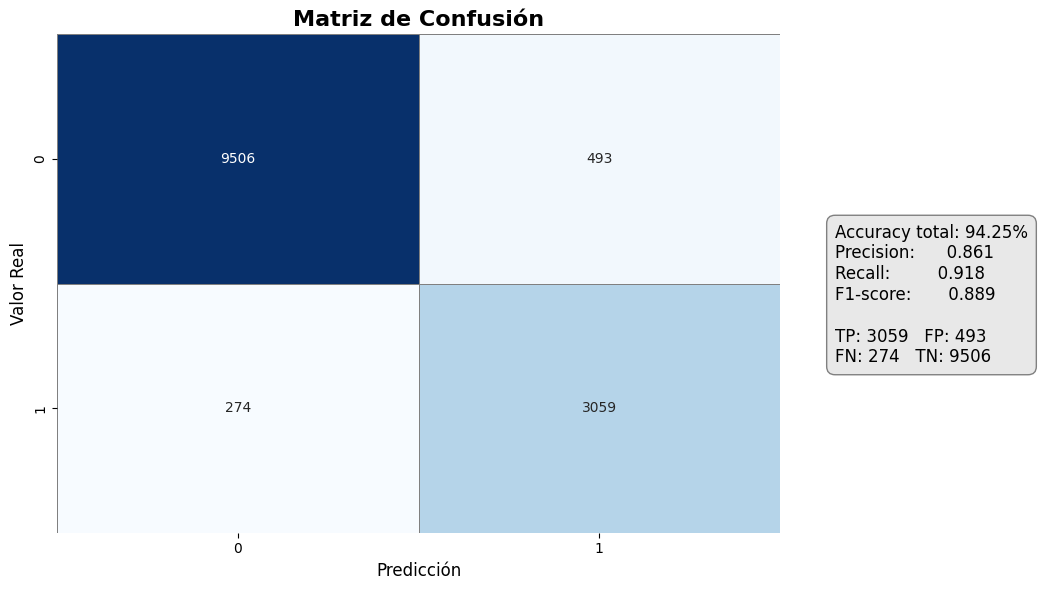

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Matriz de Confusión", fontsize=16, fontweight="bold")
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Valor Real", fontsize=12)

# Panel lateral con métricas
metrics_text = (
    f"Accuracy total: {accuracy_total:.2f}%\n"
    f"Precision:      {precision:.3f}\n"
    f"Recall:         {recall:.3f}\n"
    f"F1-score:       {f1:.3f}\n\n"
    f"TP: {tp}   FP: {fp}\n"
    f"FN: {fn}   TN: {tn}"
)

plt.gcf().text(
    1.05, 0.5, metrics_text,
    fontsize=12,
    verticalalignment='center',
    bbox=dict(boxstyle="round,pad=0.5", fc="#e8e8e8", ec="gray")
)

plt.tight_layout()
plt.show()

ROC AUC: 0.9821561664117207


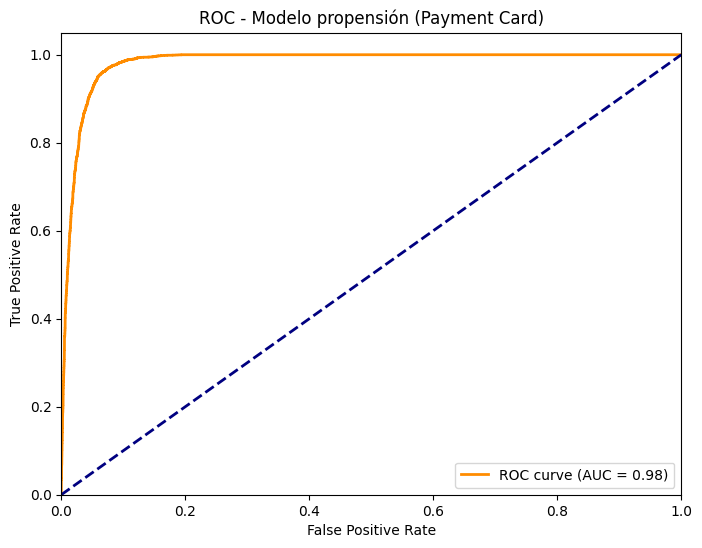

In [44]:
y_prob_test = model_us.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_prob_test))

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Modelo propensión (Payment Card)')
plt.legend(loc="lower right")
plt.show()

In [45]:
y_prob_test

array([7.9471893e-06, 2.4029032e-05, 8.3213538e-01, ..., 1.0240024e-03,
       8.1760563e-06, 2.9197019e-02], dtype=float32)

* Con el dataset total (sin balanceo):

In [46]:
X_full = df.drop(columns=["y", "pk_cid", "pk_partition"])
y_full = df["y"]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

In [47]:
y_pred_train_full = model_us.predict(X_train_full)
y_pred_test_full  = model_us.predict(X_test_full)

print("Train accuracy:", accuracy_score(y_train_full, y_pred_train_full))
print("Test accuracy:", accuracy_score(y_test_full, y_pred_test_full))
print("F1 score:", f1_score(y_test_full, y_pred_test_full))

y_pred_full = y_pred_test_full 

tn_full, fp_full, fn_full, tp_full = confusion_matrix(y_test_full, y_pred_full).ravel()

precision_full = precision_score(y_test_full, y_pred_full)
recall_full = recall_score(y_test_full, y_pred_full)
f1_full = f1_score(y_test_full, y_pred_full)

recall_positivos_full = tp_full / (tp_full + fn_full) * 100
accuracy_total_full = (tp_full + tn_full) / (tp_full + tn_full + fp_full + fn_full) * 100

# Prints (igual que los tuyos)
print(f"Verdaderos positivos (1s acertados): {tp_full}")
print(f"Falsos negativos (1s perdidos): {fn_full}")
print(f"Precision: {precision_full}")
print(f"Recall: {recall_full}")
print(f"F1 score: {f1_full}")
print(f"% de 1s acertados (recall): {recall_positivos_full:.2f}%")
print(f"% de aciertos total (accuracy): {accuracy_total_full:.2f}%")

Train accuracy: 0.9506781710056519
Test accuracy: 0.9503975641256517
F1 score: 0.12229976736457294
Verdaderos positivos (1s acertados): 3128
Falsos negativos (1s perdidos): 205
Precision: 0.06541196152237558
Recall: 0.9384938493849385
F1 score: 0.12229976736457294
% de 1s acertados (recall): 93.85%
% de aciertos total (accuracy): 95.04%


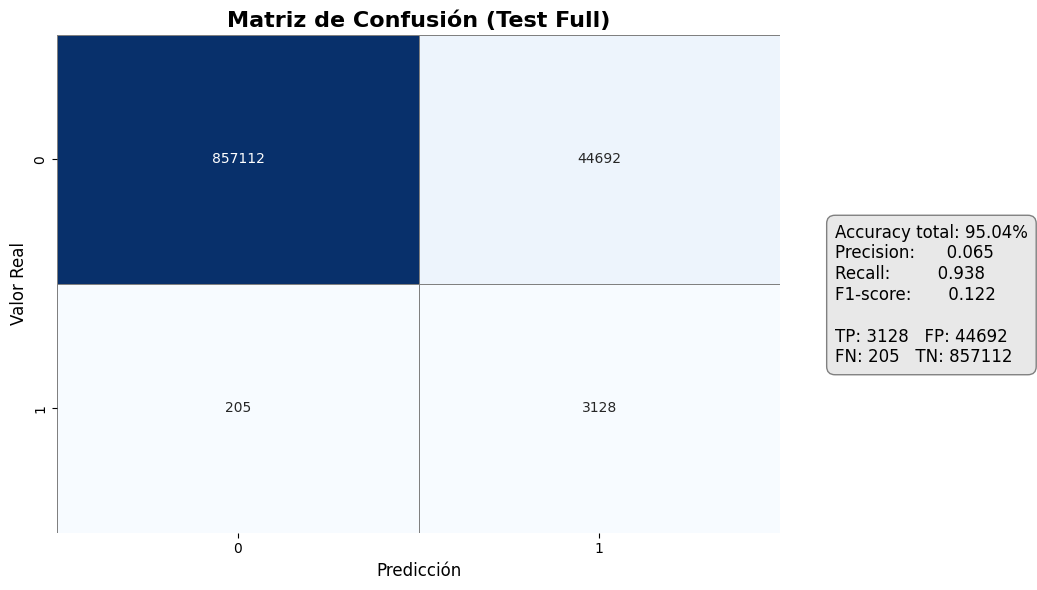

In [48]:
cm_full = confusion_matrix(y_test_full, y_pred_full)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_full,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Matriz de Confusión (Test Full)", fontsize=16, fontweight="bold")
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Valor Real", fontsize=12)

# Panel lateral con métricas
metrics_text_full = (
    f"Accuracy total: {accuracy_total_full:.2f}%\n"
    f"Precision:      {precision_full:.3f}\n"
    f"Recall:         {recall_full:.3f}\n"
    f"F1-score:       {f1_full:.3f}\n\n"
    f"TP: {tp_full}   FP: {fp_full}\n"
    f"FN: {fn_full}   TN: {tn_full}"
)

plt.gcf().text(
    1.05, 0.5, metrics_text_full,
    fontsize=12,
    verticalalignment='center',
    bbox=dict(boxstyle="round,pad=0.5", fc="#e8e8e8", ec="gray")
)

plt.tight_layout()
plt.show()

ROC AUC: 0.9840058436096747


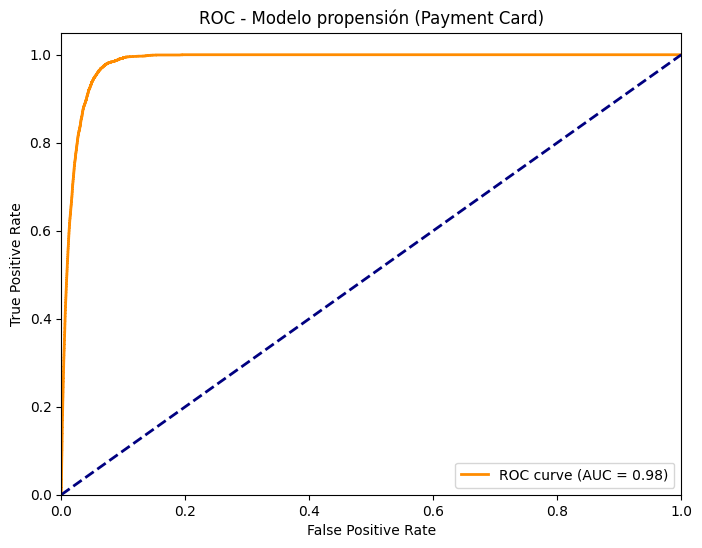

In [49]:
y_prob_test_full = model_us.predict_proba(X_test_full)[:,1]
print("ROC AUC:", roc_auc_score(y_test_full, y_prob_test_full))

fpr, tpr, thresholds = roc_curve(y_test_full, y_prob_test_full)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Modelo propensión (Payment Card)')
plt.legend(loc="lower right")
plt.show()

* Con el set de validación (penúltima partición abril 2019)

Verdaderos positivos (1s acertados): 693
Falsos negativos (1s perdidos): 787
Precision: 0.08696197766344585
Recall: 0.46824324324324323
F1 score: 0.14668218859138532
% de 1s acertados (recall): 46.82%
% de aciertos total (accuracy): 97.94%


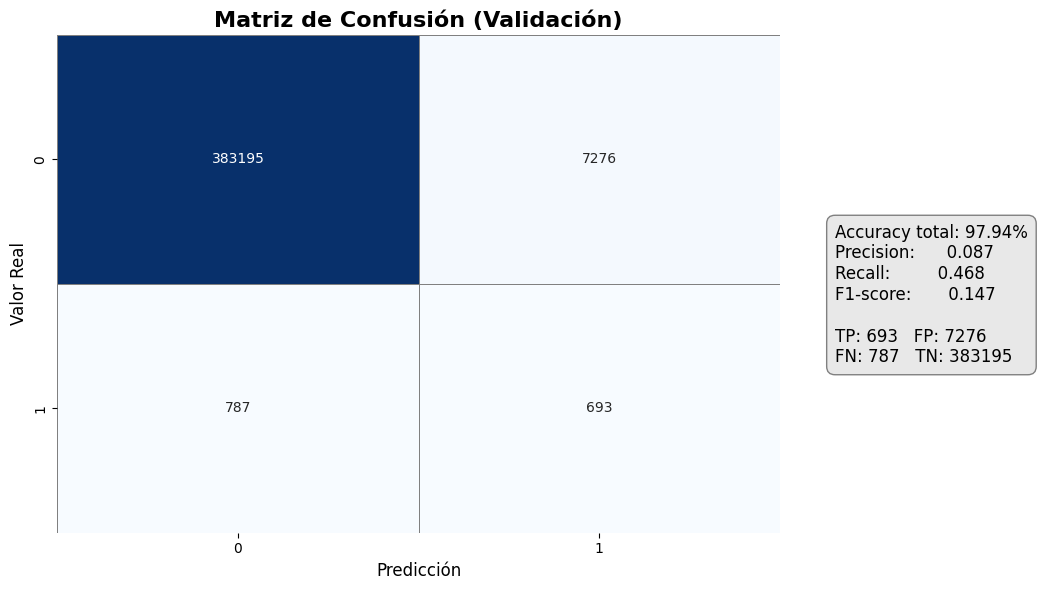

In [50]:
# Separación features / target
X_val = df_val.drop(columns=["y", "pk_cid", "pk_partition"])
y_val = df_val["y"]

# Predicciones
y_pred_val = model_us.predict(X_val)

# Métricas principales
tn_val, fp_val, fn_val, tp_val = confusion_matrix(y_val, y_pred_val).ravel()

precision_val = precision_score(y_val, y_pred_val)
recall_val = recall_score(y_val, y_pred_val)
f1_val = f1_score(y_val, y_pred_val)

recall_positivos_val = tp_val / (tp_val + fn_val) * 100
accuracy_total_val = (tp_val + tn_val) / (tp_val + tn_val + fp_val + fn_val) * 100

# Impresiones
print(f"Verdaderos positivos (1s acertados): {tp_val}")
print(f"Falsos negativos (1s perdidos): {fn_val}")
print(f"Precision: {precision_val}")
print(f"Recall: {recall_val}")
print(f"F1 score: {f1_val}")
print(f"% de 1s acertados (recall): {recall_positivos_val:.2f}%")
print(f"% de aciertos total (accuracy): {accuracy_total_val:.2f}%")

# Matriz de confusión
cm_val = confusion_matrix(y_val, y_pred_val)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Matriz de Confusión (Validación)", fontsize=16, fontweight="bold")
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Valor Real", fontsize=12)

# Panel lateral con métricas
metrics_text_val = (
    f"Accuracy total: {accuracy_total_val:.2f}%\n"
    f"Precision:      {precision_val:.3f}\n"
    f"Recall:         {recall_val:.3f}\n"
    f"F1-score:       {f1_val:.3f}\n\n"
    f"TP: {tp_val}   FP: {fp_val}\n"
    f"FN: {fn_val}   TN: {tn_val}"
)

plt.gcf().text(
    1.05, 0.5, metrics_text_val,
    fontsize=12,
    verticalalignment='center',
    bbox=dict(boxstyle="round,pad=0.5", fc="#e8e8e8", ec="gray")
)

plt.tight_layout()
plt.show()


ROC AUC: 0.9551192627586905


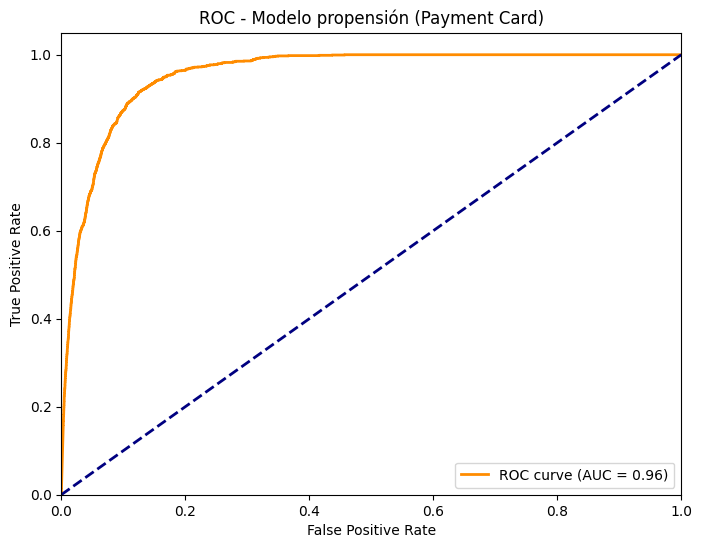

In [51]:
y_prob_val = model_us.predict_proba(X_val)[:,1]
print("ROC AUC:", roc_auc_score(y_val, y_prob_val))

fpr, tpr, thresholds = roc_curve(y_val, y_prob_val)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Modelo propensión (Payment Card)')
plt.legend(loc="lower right")
plt.show()

In [52]:
df_pred_val = pd.DataFrame({
    "pk_cid": df_val["pk_cid"].values,
    "y_real": y_val.values,
    "y_pred": y_pred_val,
    "propension": y_prob_val
})

In [53]:
# CRUZAMOS CON CLUSTERING
df_clustering = pd.read_csv('../clustering/data/processed/df_clustered.csv')
df_pred_val_clustered = df_pred_val.merge(df_clustering, on='pk_cid', how='left')
df_pred_val_clustered

,pk_cid,y_real,y_pred,propension,cluster_name
0,1000096,0.00,0,0.00,Particulares sin cuenta
1,1000113,0.00,0,0.00,Particulares sin cuenta
2,1000130,0.00,0,0.00,Particulares sin cuenta
3,1000157,0.00,0,0.00,Particulares Premium Digitales
4,1000162,0.00,0,0.00,Particulares Premium Digitales
...,...,...,...,...,...
391946,841483,1.00,0,0.00,Particulares Premium Digitales
391947,841727,1.00,0,0.10,Particulares Premium Digitales
391948,880768,1.00,0,0.00,Particulares Premium Digitales
391949,881690,1.00,0,0.00,Particulares Premium Digitales


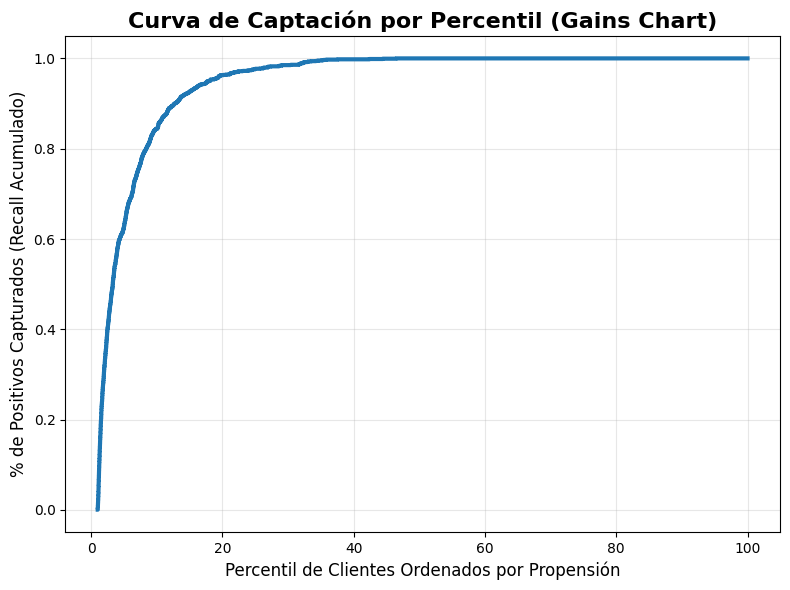

In [54]:
# Asegurar orden por propensión (de mayor a menor)
df_sorted = df_pred_val.sort_values("propension", ascending=False).reset_index(drop=True)

# Crear percentiles 1–100
df_sorted["percentil"] = np.linspace(0.01, 1.00, len(df_sorted))

# Cálculo de captación acumulada (recall progresivo)
df_sorted["captados"] = df_sorted["y_real"].cumsum()
total_positivos = df_sorted["y_real"].sum()

df_sorted["recall_acumulado"] = df_sorted["captados"] / total_positivos

# Plot
plt.figure(figsize=(8, 6))
plt.plot(df_sorted["percentil"] * 100, df_sorted["recall_acumulado"], linewidth=3)

plt.title("Curva de Captación por Percentil (Gains Chart)", fontsize=16, fontweight="bold")
plt.xlabel("Percentil de Clientes Ordenados por Propensión", fontsize=12)
plt.ylabel("% de Positivos Capturados (Recall Acumulado)", fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Total clientes: 391951
Total positivos reales: 1480
Tasa base (positivos / total): 0.0038

Percentil óptimo según F1: top 1%  → F1=0.1730, recall=0.316, precision=0.1191, clientes=3920.0
Para captar el 85% de los positivos necesitas el top 10% → clientes=39196, positivos_capturados≈1287
Para captar el 90% de los positivos necesitas el top 12% → clientes=47035, positivos_capturados≈1334

--- Primeros percentiles ---
 percentil  clientes_contactados  positivos_capturados  recall_acumulado  precision_en_topk  lift  f1_topk
         1                  3920                   467              0.32               0.12 31.55     0.17
         2                  7840                   684              0.46               0.09 23.11     0.15
         3                 11759                   851              0.57               0.07 19.17     0.13
         4                 15679                   924              0.62               0.06 15.61     0.11
         5                 19598              

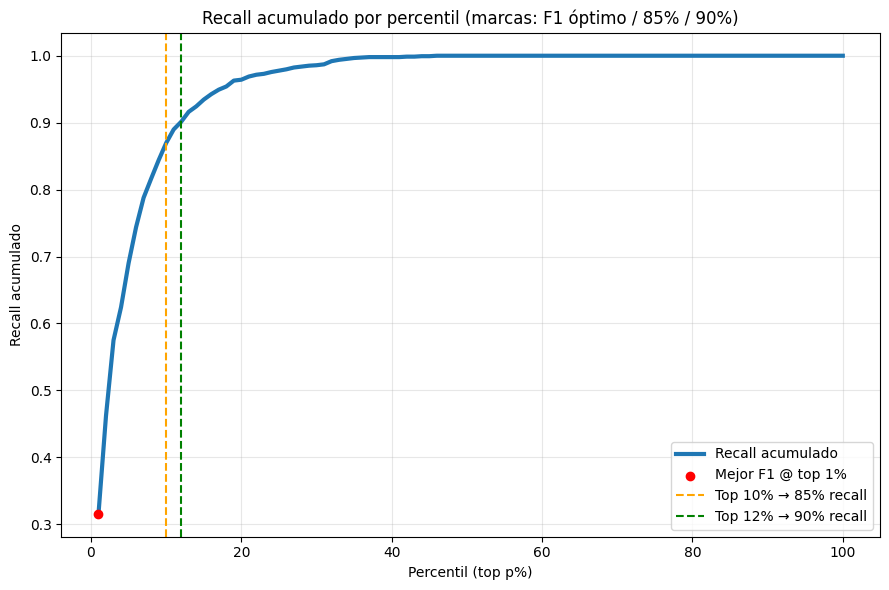


--- Percentiles (muestra) ---
 percentil  clientes_contactados  positivos_capturados  recall_acumulado  precision_en_topk  lift  f1_topk
         1                  3920                   467              0.32               0.12 31.55     0.17
         2                  7840                   684              0.46               0.09 23.11     0.15
         3                 11759                   851              0.57               0.07 19.17     0.13
         4                 15679                   924              0.62               0.06 15.61     0.11
         5                 19598                  1021              0.69               0.05 13.80     0.10
         6                 23518                  1101              0.74               0.05 12.40     0.09
         7                 27437                  1166              0.79               0.04 11.25     0.08
         8                 31357                  1208              0.82               0.04 10.20     0.07
      

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------- Asegurarse de tener df_pred_val
# df_pred_val debe contener columnas: "pk_cid", "y_real", "propension"
# Si no existe, crear a partir de df_val y el modelo como en pasos anteriores.

# Ordenar por propensión descendente
df_sorted = df_pred_val.sort_values("propension", ascending=False).reset_index(drop=True)
n_total = len(df_sorted)
total_positivos = df_sorted["y_real"].sum()
overall_rate = total_positivos / n_total

results = []

for p in range(1, 101):  # percentiles 1..100
    cutoff_idx = int(np.ceil((p/100) * n_total))  # número de clientes en el top p%
    if cutoff_idx == 0:
        cutoff_idx = 1
    topk = df_sorted.iloc[:cutoff_idx]

    clientes_contactados = len(topk)
    positivos_capturados = int(topk["y_real"].sum())
    recall_acumulado = positivos_capturados / total_positivos if total_positivos > 0 else 0.0
    precision_en_topk = positivos_capturados / clientes_contactados if clientes_contactados > 0 else 0.0
    lift = (precision_en_topk / overall_rate) if overall_rate > 0 else np.nan

    # F1 para este punto (considerando que la "predicción positiva" son los del top p%)
    if precision_en_topk + recall_acumulado > 0:
        f1_topk = 2 * precision_en_topk * recall_acumulado / (precision_en_topk + recall_acumulado)
    else:
        f1_topk = 0.0

    results.append({
        "percentil": p,
        "clientes_contactados": clientes_contactados,
        "positivos_capturados": positivos_capturados,
        "recall_acumulado": recall_acumulado,
        "precision_en_topk": precision_en_topk,
        "lift": lift,
        "f1_topk": f1_topk
    })

df_percentiles = pd.DataFrame(results)

# Tabla deciles (10% por bloque) con métricas por bloque y acumuladas
deciles = []
for d in range(1, 11):
    p_low = (d-1)*10
    p_high = d*10
    idx_low = int(np.floor(p_low/100 * n_total))
    idx_high = int(np.ceil(p_high/100 * n_total))
    block = df_sorted.iloc[idx_low:idx_high]
    block_clients = len(block)
    block_positives = block["y_real"].sum()
    block_precision = block_positives / block_clients if block_clients>0 else 0
    # acumulado hasta este decil
    acum = df_sorted.iloc[:idx_high]
    acum_positivos = acum["y_real"].sum()
    acum_recall = acum_positivos / total_positivos if total_positivos>0 else 0

    deciles.append({
        "decil": d,
        "rango_percentil": f"{p_low+1}-{p_high}",
        "clientes_en_decil": block_clients,
        "positivos_en_decil": int(block_positives),
        "precision_decil": block_precision,
        "recall_acumulado_hasta_decil": acum_recall
    })

df_deciles = pd.DataFrame(deciles)

# Buscar percentil óptimo por F1
best_row = df_percentiles.loc[df_percentiles["f1_topk"].idxmax()]
best_percentil = int(best_row["percentil"])
best_f1 = best_row["f1_topk"]
best_recall = best_row["recall_acumulado"]
best_precision = best_row["precision_en_topk"]
best_clients = best_row["clientes_contactados"]

# Percentiles necesarios para alcanzar X% recall
def percentil_para_recall(objetivo_recall):
    # primer percentil con recall_acumulado >= objetivo
    df_tmp = df_percentiles[df_percentiles["recall_acumulado"] >= objetivo_recall]
    if len(df_tmp) == 0:
        return None
    row = df_tmp.iloc[0]
    return int(row["percentil"]), int(row["clientes_contactados"]), int(row["positivos_capturados"])

p85 = percentil_para_recall(0.85)
p90 = percentil_para_recall(0.90)

# Mostrar resultados clave
print("Total clientes:", n_total)
print("Total positivos reales:", int(total_positivos))
print("Tasa base (positivos / total): {:.4f}".format(overall_rate))
print()
print(f"Percentil óptimo según F1: top {best_percentil}%  → F1={best_f1:.4f}, recall={best_recall:.3f}, precision={best_precision:.4f}, clientes={best_clients}")
if p85:
    print(f"Para captar el 85% de los positivos necesitas el top {p85[0]}% → clientes={p85[1]}, positivos_capturados≈{p85[2]}")
else:
    print("No se alcanza 85% de recall en 100% (imposible si hay positivos).")
if p90:
    print(f"Para captar el 90% de los positivos necesitas el top {p90[0]}% → clientes={p90[1]}, positivos_capturados≈{p90[2]}")
else:
    print("No se alcanza 90% de recall con el rango 1-100%.")

# Mostrar primeras filas de las tablas
print("\n--- Primeros percentiles ---")
print(df_percentiles.head(10).to_string(index=False))

print("\n--- Tabla deciles ---")
print(df_deciles.to_string(index=False))

# Plot de recall acumulado + marcar cortes
plt.figure(figsize=(9,6))
plt.plot(df_percentiles["percentil"], df_percentiles["recall_acumulado"], linewidth=3, label="Recall acumulado")
plt.scatter([best_percentil], [best_recall], color='red', zorder=5, label=f"Mejor F1 @ top {best_percentil}%")
if p85:
    plt.axvline(p85[0], color='orange', linestyle='--', label=f"Top {p85[0]}% → 85% recall")
if p90:
    plt.axvline(p90[0], color='green', linestyle='--', label=f"Top {p90[0]}% → 90% recall")
plt.xlabel("Percentil (top p%)")
plt.ylabel("Recall acumulado")
plt.title("Recall acumulado por percentil (marcas: F1 óptimo / 85% / 90%)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Devolver tablas para inspección
df_percentiles_display = df_percentiles.copy()
df_percentiles_display["recall_acumulado"] = df_percentiles_display["recall_acumulado"].round(4)
df_percentiles_display["precision_en_topk"] = df_percentiles_display["precision_en_topk"].round(4)
df_percentiles_display["lift"] = df_percentiles_display["lift"].round(2)
df_percentiles_display["f1_topk"] = df_percentiles_display["f1_topk"].round(4)

print("\n--- Percentiles (muestra) ---")
print(df_percentiles_display.head(20).to_string(index=False))

# Si quieres exportar:
# df_percentiles.to_csv("percentiles_metrics.csv", index=False)
# df_deciles.to_csv("deciles_metrics.csv", index=False)


In [56]:
# CRUZAMOS CON CLUSTERING
df_clustering = pd.read_csv('../clustering/data/processed/df_clustered.csv')
df_pred_val_clustered = df_pred_val.merge(df_clustering, on='pk_cid', how='left')
df_sorted_clustered = df_pred_val_clustered.sort_values("propension", ascending=False).reset_index(drop=True)
df_sorted_clustered["percentil"] = np.linspace(0.01, 1.00, len(df_sorted_clustered))
df_sorted_clustered

,pk_cid,y_real,y_pred,propension,cluster_name,percentil
0,1542853,1.00,1,1.00,Particulares Premium Digitales,0.01
1,1544313,0.00,1,1.00,Particulares Premium Digitales,0.01
2,1491217,1.00,1,1.00,Particulares Premium Digitales,0.01
3,1543858,0.00,1,1.00,Particulares Premium Digitales,0.01
4,1546660,0.00,1,1.00,Particulares Premium Digitales,0.01
...,...,...,...,...,...,...
391946,1036985,0.00,0,0.00,Jóvenes Básicos Activos,1.00
391947,1271705,0.00,0,0.00,NaN,1.00
391948,1306500,0.00,0,0.00,NaN,1.00
391949,1033236,0.00,0,0.00,NaN,1.00


In [57]:
cluster_stats = []
total_positivos = tp_val + fn_val  # positivos reales = verdaderos positivos + falsos negativos

for p in range(1, 101):  # percentiles 1..100
    cutoff_idx = int(np.ceil((p/100) * len(df_sorted_clustered)))
    topk = df_sorted_clustered.iloc[:cutoff_idx]
    
    cluster_counts = topk["cluster_name"].value_counts(normalize=False)
    cluster_recall = topk.groupby("cluster_name")["y_real"].sum()
    
    for cluster in df_sorted_clustered["cluster_name"].unique():
        cluster_stats.append({
            "percentil": p,
            "cluster": cluster,
            "clientes_en_top_p": int(cluster_counts.get(cluster, 0)),
            "positivos_capturados": int(cluster_recall.get(cluster, 0)),
            "recall_cluster": cluster_recall.get(cluster, 0) / total_positivos if total_positivos>0 else 0,
            "pct_clientes": cluster_counts.get(cluster, 0) / cutoff_idx if cutoff_idx>0 else 0
        })

df_clusters_percentiles = pd.DataFrame(cluster_stats)
df_clusters_percentiles

,percentil,cluster,clientes_en_top_p,positivos_capturados,recall_cluster,pct_clientes
0,1,Particulares Premium Digitales,3075,434,0.29,0.78
1,1,Jóvenes Potenciales,139,22,0.01,0.04
2,1,Particulares sin cuenta,527,0,0.00,0.13
3,1,Leads Jóvenes,31,0,0.00,0.01
4,1,Jóvenes Recientes,98,9,0.01,0.03
...,...,...,...,...,...,...
695,100,Particulares sin cuenta,46982,6,0.00,0.12
696,100,Leads Jóvenes,60649,0,0.00,0.15
697,100,Jóvenes Recientes,70990,66,0.04,0.18
698,100,Jóvenes Básicos Activos,43429,28,0.02,0.11


In [58]:
df_clusters_percentiles[df_clusters_percentiles["percentil"]==1].clientes_en_top_p.sum()

3920

In [59]:
dominant_cluster = df_clusters_percentiles.groupby("percentil").apply(
    lambda x: x.loc[x["clientes_en_top_p"].idxmax(), "cluster"]
).reset_index(name="cluster_predominante")

print(dominant_cluster.head(20))


    percentil            cluster_predominante
0           1  Particulares Premium Digitales
1           2  Particulares Premium Digitales
2           3  Particulares Premium Digitales
3           4  Particulares Premium Digitales
4           5  Particulares Premium Digitales
5           6  Particulares Premium Digitales
6           7  Particulares Premium Digitales
7           8  Particulares Premium Digitales
8           9  Particulares Premium Digitales
9          10  Particulares Premium Digitales
10         11  Particulares Premium Digitales
11         12  Particulares Premium Digitales
12         13  Particulares Premium Digitales
13         14  Particulares Premium Digitales
14         15  Particulares Premium Digitales
15         16  Particulares Premium Digitales
16         17  Particulares Premium Digitales
17         18  Particulares Premium Digitales
18         19  Particulares Premium Digitales
19         20  Particulares Premium Digitales


/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_61639/2346849404.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dominant_cluster = df_clusters_percentiles.groupby("percentil").apply(


# 3. Final Prediction

In [114]:
# Nos quedamos con los clientes vivos de la ultima partición para predecir
df_final = df_last_partition.merge(df_non_deceased_last_partition[['pk_cid']].drop_duplicates(), on ='pk_cid', how = 'inner')
df_final

,pk_cid,pk_partition,active_customer,age,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,pension_plan,emc_account,em_acount,z_months_since_entry,z_partition_segment_changed,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,month_sin,month_cos,dayofyear_sin,dayofyear_cos,weekday_sin,weekday_cos,region_code_freq,entry_channel_KAT,entry_channel_KFA,entry_channel_KFC,entry_channel_KHD,entry_channel_KHE,entry_channel_KHK,entry_channel_KHM,entry_channel_KHN,entry_channel_KHQ,entry_channel_Other,segment_01 - TOP,segment_02 - PARTICULARES,segment_03 - UNIVERSITARIO,gender_H,gender_V,y
0,1000096,2019-05-01,1.00,0.08,0.00,0,0,0,0,0,0,0.00,0,0,1.00,0,0,0,0.00,0,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.19,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
1,1000113,2019-05-01,0.00,0.50,0.00,0,0,0,0,0,0,0.00,0,0,0.94,0,0,0,0.00,0,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
2,1000130,2019-05-01,1.00,0.41,0.00,0,0,0,0,0,0,0.00,0,0,0.26,0,0,0,0.00,0,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.19,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
3,1000157,2019-05-01,1.00,0.41,0.00,0,0,0,0,0,0,0.00,0,1,0.74,0,0,0,0.14,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.06,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
4,1000162,2019-05-01,1.00,0.33,0.00,0,0,0,0,0,0,0.00,0,1,0.28,0,0,0,0.14,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393751,998325,2019-05-01,1.00,0.31,0.00,0,0,0,0,0,0,0.00,0,1,0.64,0,0,0,0.14,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.06,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
393752,998837,2019-05-01,1.00,0.34,0.00,0,0,0,0,0,0,0.00,0,1,0.23,0,0,0,0.14,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.05,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
393753,999706,2019-05-01,0.00,0.12,0.00,0,0,0,0,0,0,0.00,0,0,0.09,0,0,0,0.00,0,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.19,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
393754,999825,2019-05-01,1.00,0.37,0.00,0,0,0,0,0,0,0.00,0,1,0.53,0,0,0,0.14,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.01,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00


In [115]:
print("Número de registros (last_partition): {}".format(df_final.pk_cid.count())) #393756
print("Número de ids únicos (last_partition): {}".format(df_final.pk_cid.nunique())) #393756
print("Número de particiones únicos (last_partition): {}".format(df_final.pk_partition.nunique())) #1

Número de registros (last_partition): 393756
Número de ids únicos (last_partition): 393756
Número de particiones únicos (last_partition): 1


In [116]:
X_last_partition = df_final.drop(columns=["y", "pk_cid", "pk_partition"])
y_prob_last_partition = model_us.predict_proba(X_last_partition)[:,1]

In [117]:
df_scored = df_final.copy()
df_scored["proba"] = y_prob_last_partition

In [118]:
df_scored[['pk_cid','proba']].sort_values(by='proba', ascending=False)

,pk_cid,proba
386375,1548619,1.00
388618,1551597,1.00
386205,1548396,1.00
388520,1551470,1.00
384899,1546492,1.00
...,...,...
150716,1211942,0.00
98596,1146917,0.00
98342,1146608,0.00
22406,1036985,0.00


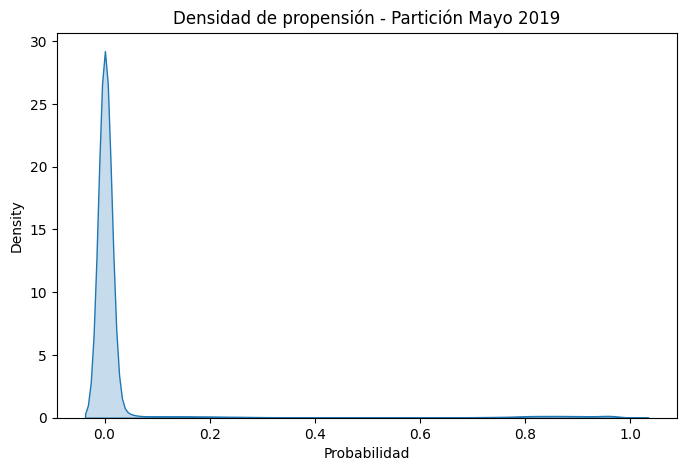

In [119]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.kdeplot(df_scored["proba"], fill=True)
plt.title("Densidad de propensión - Partición Mayo 2019")
plt.xlabel("Probabilidad")
plt.show()

In [120]:
# importamos el dataframe de products para ver quienes tienen algún producto de inversión
df_customer_products = pd.read_csv('../data/datasets_TFM + diccionario/customer_products.csv', sep=',')
df_customer_products.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_customer_products_last_partition = df_customer_products[df_customer_products["pk_partition"]==df_customer_products["pk_partition"].max()]

In [121]:
products = ['credit_card', 'debit_card']
df_customer_products_last_partition = df_customer_products_last_partition[['pk_cid']+products].drop_duplicates()
df_customer_products_last_partition['have_paymentcards_products'] = df_customer_products_last_partition[products].sum(axis=1)

In [122]:
df_customer_products_last_partition.have_paymentcards_products.value_counts()

have_paymentcards_products
0    398134
1     41660
2      3201
Name: count, dtype: int64

Importante tener en cuenta:

- A XXX clientes "se les va a poder vender" cualquier tipo de tarjeta.
- XXX clientes ya tienen una tarjeta, se le podrá intentar vender la otra.
- XXX ya tienen 2 no se les podrá vender nada.

In [123]:
df_customer_products_last_partition = df_customer_products_last_partition[df_customer_products_last_partition["have_paymentcards_products"]<2]

In [124]:
df_scored = df_scored.merge(df_customer_products_last_partition, on='pk_cid', how='left')

In [125]:
df_scored_final = df_scored.copy()

In [126]:
def assign_segment(proba):
    if proba >= 0.8:
        return "Top"
    elif proba >= 0.6:
        return "High"
    elif proba >= 0.5:
        return "Medium"
    elif proba >= 0.4:
        return "Mid-Low"
    else:
        return "Low"


df_scored_final["propensity_segment"] = df_scored_final["proba"].apply(assign_segment)
# df_scored_final = df_scored_final[["pk_cid", "proba", "propensity_segment"]].rename(columns={"proba": "propensity_score"})
df_scored_final = df_scored_final[["pk_cid",'credit_card', 'debit_card', 'have_paymentcards_products', "proba", "propensity_segment"]].rename(columns={"proba": "propensity_score"})


print(df_scored_final["propensity_segment"].value_counts())
print("-----------------------")
print(df_scored_final["propensity_segment"].value_counts(normalize=True))

propensity_segment
Low        377953
Top          9775
High         4116
Mid-Low       997
Medium        915
Name: count, dtype: int64
-----------------------
propensity_segment
Low       0.96
Top       0.02
High      0.01
Mid-Low   0.00
Medium    0.00
Name: proportion, dtype: float64


In [127]:
df_scored_final.head()

,pk_cid,credit_card,debit_card,have_paymentcards_products,propensity_score,propensity_segment
0,1000096,0,0,0,0.00,Low
1,1000113,0,0,0,0.00,Low
2,1000130,0,0,0,0.00,Low
3,1000157,0,0,0,0.00,Low
4,1000162,0,0,0,0.00,Low


In [128]:
df_scored_final.groupby("propensity_segment")["propensity_score"].agg(["count", "mean", "std", "min", "max"])

,count,mean,std,min,max
propensity_segment,,,,,
High,4116,0.73,0.06,0.60,0.80
Low,377953,0.01,0.04,0.00,0.40
Medium,915,0.55,0.03,0.50,0.60
Mid-Low,997,0.45,0.03,0.40,0.50
Top,9775,0.89,0.05,0.80,1.00


In [129]:
df_scored_final.to_csv('data/processed/df_payment_card_scored.csv')